## 09. Verifying transformations made with DisPerSE

The following notebook verifies if the coordinates are correctly transformed in the previous notebook 08.


**Author**: Soumya Shreeram <br/>
**Contact email**: shreeram@mpe.mpg.de <br/>
**Date created**: 28th September 2022 <br/>
**Date last editted**: 28th September 2022

In [1]:
# astropy modules
import astropy.units as u
import astropy.io.fits as fits
from astropy.table import Table, Column, QTable
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18, z_at_value

from astrotools import healpytools as hpt
from gdpyc import GasMap
    
import numpy as np

# system imports
import os
import sys
import importlib as ib
import glob
import copy

# plotting imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib import cm
import seaborn as sns

import healpy as hp
from healpy.newvisufunc import projview, newprojplot


In [2]:
import filaments as fo

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
mpl.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : 'serif',
        'weight' : 'medium',
        'size'   : 16}
mpl.rc('font', **font)

bright_colors = sns.color_palette("bright")

Input parameters

In [5]:
base_dir = "/data53s/shreeram/Filament_stacking"

# decides wether to produce the fits file for critical points "cp", filaments "fil" or "cp_field"
keyword = "fil" 

# system keywords
data_set = 'lc_north_dis' # 'legacy_north_dis' for Legacy MGS, 'lc_north_dis' for LOWZ+CMASS
smoothing_density_f = 'None' # 'None' or 'SD1' or 'SD2'
persistence =  3 # 3 or 5
smoothing_skeleton = 'None' # None or 'S001'
base_name = f"{data_set}_{smoothing_density_f}_{persistence:.1f}_{smoothing_skeleton}"

ra_c_MGS, dec_c_MGS = 186.183, 26.845
"""
For the healpy map
"""
z_low, z_high = 0.1, 0.2
z_range = (z_low, z_high)

# can change this default value in the class objects below
NSIDE = 512
val_erass1 = 2
val_combined = val_erass1+1

milky_way_map = fo.get_milky_way()

In [6]:
this_file = fo.DisPerSEcatalog(data_set=data_set, 
                               smoothing_density_f = smoothing_density_f, 
                               persistence = persistence, 
                               smoothing_skeleton = smoothing_skeleton,
                               section_keyword = keyword)


INFO:DisPerSEcatalog:<DisPerSEcatalog(data_set=lc_north_dis, smoothing_density_f=None, persistence=3, smoothing_skeleton=None)>


The SDSS LOWZ+CMASS survey data was obtained from the following website: https://data.sdss.org/sas/dr12/boss/lss/

In [7]:
table_fil = Table.read(f'{this_file.catalog_dir_reformatted}/{base_name}_{keyword}.fit')
table_fil_extras = Table.read(f'{this_file.catalog_dir_reformatted}/{base_name}_{keyword}_extras.fit')

table_galaxies = Table.read(f"{base_dir}/data/Galaxy_catalogues/galaxy_DR12v5_CMASSLOWZTOT_North.fits")

In [16]:
def plot_healpy_maps(this_file, base_name, z_low = 0.1, z_high = 0.2, NSIDE = 512, 
                     title='LOWZ+CMASS', id_type='filaments',vmax=1.1, ra_c_MGS = 186.183, 
                     dec_c_MGS = 26.845, ra_c_LOWZ = 184.894, dec_c_LOWZ = 28.153,
                    keyword='fil'):
    "Function to quickly check the generated fits tables"
    example_with_extras = f'{base_name}_{keyword}_extras.fit'
    table_extra = Table.read(f'{this_file.catalog_dir_reformatted}/{example_with_extras}')
    select_z = (z_low < table_extra['redshift']) & (table_extra['redshift'] < z_high)
    
    milky_way_map = fo.get_milky_way()
    if title == 'LOWZ+CMASS':
        ra_c, dec_c = ra_c_LOWZ, dec_c_LOWZ
    if title == 'MGS':
        ra_c, dec_c = ra_c_MGS, dec_c_MGS
    
    ra, dec = table_extra['RA'] + ra_c, table_extra['DEC'] +  dec_c
    fil_map = fo.produce_healpy_map(NSIDE, ra[select_z], dec[select_z])

    # plot healpy map
    fo.healpy_mollview(fil_map+milky_way_map, title=f"{title}, {id_type}", vmax=vmax, 
                       rot=[270, 0])
    return fil_map, ra, dec 

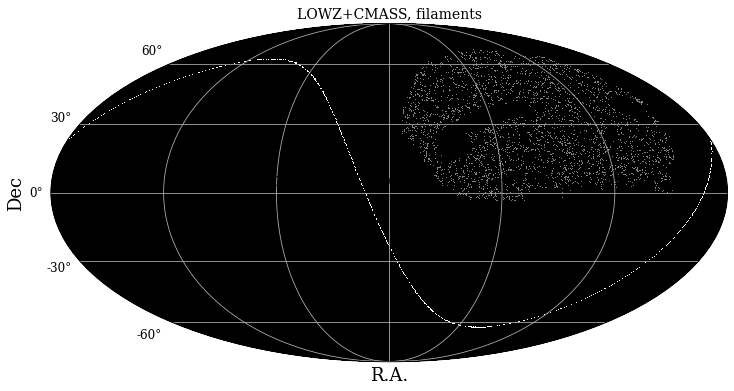

In [17]:
fil_map, ra_fil, dec_fil = plot_healpy_maps(this_file, base_name, title='LOWZ+CMASS',  NSIDE=256)

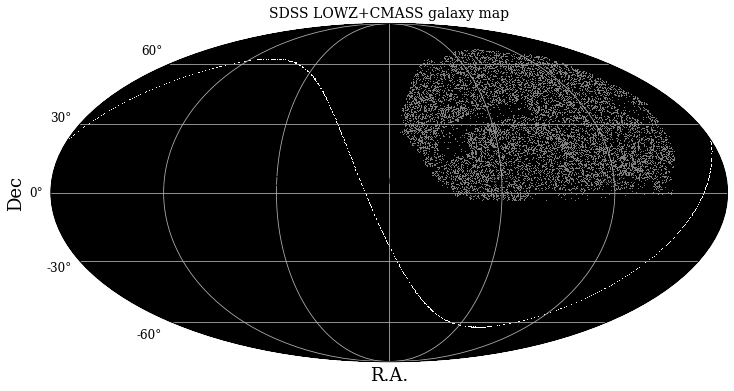

In [15]:
ra_gal, dec_gal, Z_gal = table_galaxies['RA'], table_galaxies['DEC'], table_galaxies['Z']

select_z = (z_low < Z_gal) & (Z_gal < z_high)
galaxy_map = fo.produce_healpy_map(256, ra_gal[select_z], dec_gal[select_z])

# plot healpy map
fo.healpy_mollview(galaxy_map+milky_way_map, title=f"SDSS LOWZ+CMASS galaxy map", vmax=4, 
                       rot=[270, 0])

... so looks like the transformations were made correctly :=)